Dataset shape after preprocessing: (768, 8)
First 5 rows of scaled data:
[[ 6.39947260e-01  8.65108070e-01 -3.35182392e-02  6.65502121e-01
  -3.34507888e-16  1.66291742e-01  4.68491977e-01  1.42599540e+00]
 [-8.44885053e-01 -1.20616153e+00 -5.29859033e-01 -1.74633816e-02
  -3.34507888e-16 -8.52531177e-01 -3.65060778e-01 -1.90671905e-01]
 [ 1.23388019e+00  2.01581340e+00 -6.95305964e-01  8.08793628e-16
  -3.34507888e-16 -1.33283341e+00  6.04397318e-01 -1.05584152e-01]
 [-8.44885053e-01 -1.07465235e+00 -5.29859033e-01 -7.00428884e-01
  -7.24388738e-01 -6.34211980e-01 -9.20762614e-01 -1.04154944e+00]
 [-1.14185152e+00  5.03457822e-01 -2.68066914e+00  6.65502121e-01
   1.46550563e-01  1.54897999e+00  5.48490910e+00 -2.04963989e-02]]

Running K-Means for Elbow Method (calculating WCSS for K from 1 to 10)...
  K=1, WCSS=6144.00
  K=2, WCSS=4961.89
  K=3, WCSS=4344.53
  K=4, WCSS=3942.18
  K=5, WCSS=3854.46
  K=6, WCSS=3500.36
  K=7, WCSS=3322.47
  K=8, WCSS=3217.63
  K=9, WCSS=3112.28
  K=10

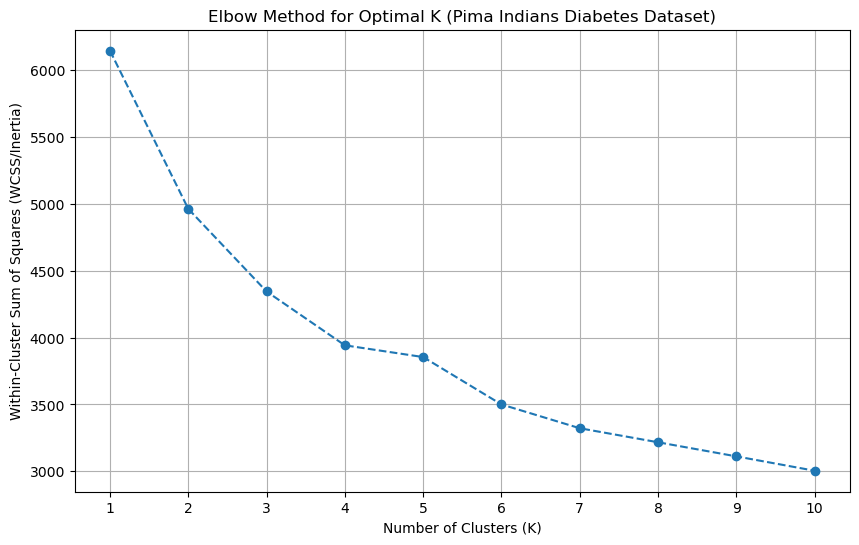


--- Running K-Means with Optimal K = 6 ---

Final Centroids (K=6):
  Cluster 0: [ 1.40223913 -0.38120372  0.19319085  0.2616724  -0.0937962   0.10552038
 -0.19020304  0.62670651]
  Cluster 1: [-0.61371356 -0.04317672  0.14423135  0.76720827 -0.13380733  0.95380961
 -0.14844412 -0.51166163]
  Cluster 2: [-0.51597399 -0.57096518 -0.55923667 -0.72995225 -0.40119027 -0.74491557
 -0.23174239 -0.66356998]
  Cluster 3: [-0.05135172  0.49052249  0.1883715   0.34295557  0.1443714   0.38164625
  2.28536567  0.16920744]
  Cluster 4: [ 0.47364604  0.97320862  0.70226422 -0.10112602  0.02850238 -0.19522747
 -0.27692163  1.31027606]
  Cluster 5: [-0.05832523  1.28007285 -0.20343671  0.36708927  3.3131688   0.41647374
  0.06273495 -0.04579276]

First 20 Cluster Labels (K=6):
[4 2 4 2 3 2 2 0 5 4 1 0 3 5 4 0 1 0 1 1]

WCSS for K=6: 3500.36

Distribution of 'Outcome' within each cluster (K=6):
Outcome         0         1
Cluster                    
0        0.551181  0.448819
1        0.628743  0.3712

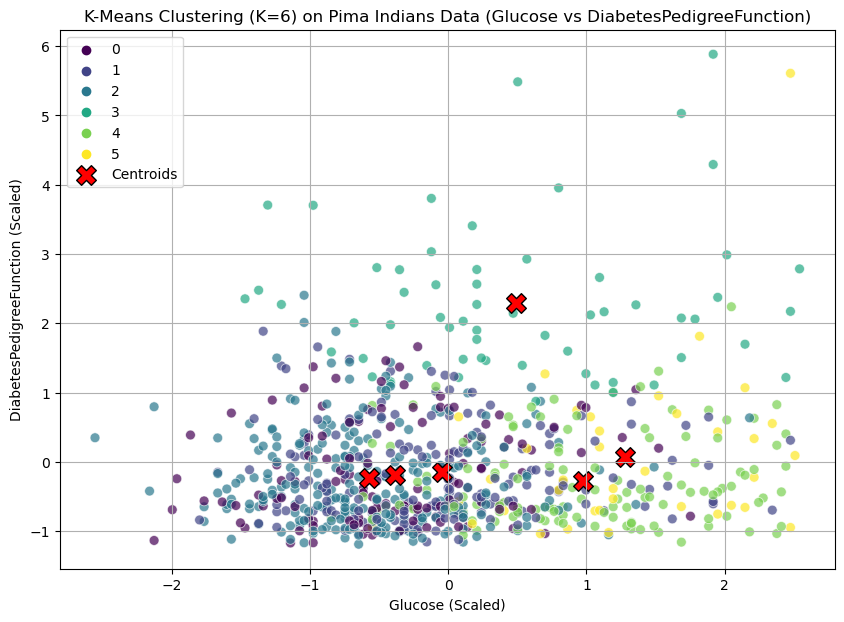

In [1]:
import numpy as np
import random
import pandas as pd # For loading the dataset
import matplotlib.pyplot as plt # For visualization (optional, but highly recommended)
import seaborn as sns # For visualization (optional)

class KMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4, random_state=None):
        """
        Initializes the K-Means clustering algorithm.

        Args:
            n_clusters (int): The number of clusters (K).
            max_iter (int): The maximum number of iterations for the algorithm.
            tol (float): The tolerance for checking convergence. If the centroids
                         move less than this value, the algorithm is considered converged.
            random_state (int, optional): Seed for the random number generator for
                                          centroid initialization. Makes results reproducible.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None # To store the cluster assignments for each data point
        self.inertia_ = None # To store the sum of squared distances (WCSS)

        if self.random_state is not None:
            np.random.seed(self.random_state)
            random.seed(self.random_state) # For random.sample

    def _euclidean_distance(self, point1, point2):
        """Calculates the Euclidean distance between two NumPy arrays."""
        return np.sqrt(np.sum((point1 - point2)**2))

    def _calculate_centroid(self, points):
        """Calculates the mean of a list of NumPy arrays (points)."""
        if points.size == 0: # Check if the array of points is empty
            return None 
        return np.mean(points, axis=0)

    def fit(self, X):
        """
        Fits the K-Means model to the training data X.

        Args:
            X (np.ndarray): The input data as a NumPy array, where each row
                            is a data point.
        """
        if not isinstance(X, np.ndarray):
            X = np.array(X, dtype=float) # Convert to NumPy array
        
        if X.ndim != 2:
            raise ValueError("Input data X must be a 2D array (samples x features).")
        if X.shape[0] == 0:
            raise ValueError("Input data X cannot be empty.")
        if self.n_clusters > X.shape[0]:
            raise ValueError(f"Number of clusters ({self.n_clusters}) cannot be greater than the number of data points ({X.shape[0]}).")

        num_samples = X.shape[0]  # We only need num_samples

        # Step 1: Initialize Centroids
        initial_indices = np.random.choice(num_samples, self.n_clusters, replace=False)
        self.centroids = X[initial_indices].astype(float)

        # Initialize WCSS for tracking
        self.inertia_ = float('inf') 

        for _ in range(self.max_iter):  # Using _ since we don't use the iteration variable
            # Step 2: Assign Data Points to Clusters
            X_expanded = X[:, np.newaxis, :]
            centroids_expanded = self.centroids[np.newaxis, :, :]

            distances_sq = np.sum((X_expanded - centroids_expanded)**2, axis=2)
            self.labels_ = np.argmin(distances_sq, axis=1)

            # Calculate current WCSS (Sum of squared distances from points to their assigned centroid)
            current_inertia = 0
            for i in range(num_samples):
                current_inertia += distances_sq[i, self.labels_[i]]

            # Step 3: Update Centroids
            new_centroids = np.zeros_like(self.centroids)
            centroids_moved_significantly = False

            for i in range(self.n_clusters):
                cluster_points = X[self.labels_ == i]

                if cluster_points.size > 0:
                    new_c = self._calculate_centroid(cluster_points)
                else:
                    # Handle empty cluster: re-initialize with a random data point
                    new_c = X[np.random.choice(num_samples, 1, replace=False)].flatten()
                
                if np.linalg.norm(new_c - self.centroids[i]) > self.tol:
                    centroids_moved_significantly = True
                
                new_centroids[i] = new_c
            
            self.centroids = new_centroids
            self.inertia_ = current_inertia # Update inertia for tracking

            # Check for convergence
            if not centroids_moved_significantly:
                # print(f"K-Means converged after {iteration + 1} iterations.")
                break

    def predict(self, X):
        """
        Predicts the cluster for each data point in X.

        Args:
            X (np.ndarray): The input data as a NumPy array to predict clusters for.

        Returns:
            np.ndarray: A NumPy array of cluster labels for each data point in X.
        """
        if self.centroids is None:
            raise RuntimeError("K-Means model has not been fitted yet. Call fit() first.")
        
        if not isinstance(X, np.ndarray):
            X = np.array(X, dtype=float)

        if X.ndim != 2:
            raise ValueError("Input data X must be a 2D array (samples x features).")
        if X.shape[0] == 0:
            return np.array([])

        X_expanded = X[:, np.newaxis, :]
        centroids_expanded = self.centroids[np.newaxis, :, :]
        distances_sq = np.sum((X_expanded - centroids_expanded)**2, axis=2)
        
        return np.argmin(distances_sq, axis=1)

# --- Main execution with Pima Indians Diabetes Dataset ---
if __name__ == "__main__":
    # --- Load the dataset ---
    try:
        # Assuming diabetes.csv is in the same directory as this script
        df = pd.read_csv('../datasets/pima_indians_diabetes_with_header.csv')
        if 'Outcome' not in df.columns:
            raise KeyError("'Outcome' column not found in the dataset")
    except FileNotFoundError:
        print("Error: 'diabetes.csv' not found.")
        print("Please download the Pima Indians Diabetes Dataset from Kaggle (or UCI ML Repository) and place 'diabetes.csv' in the same directory as this script.")
        exit()
    except KeyError as e:
        print(f"Error: {e}")
        print("Please ensure the dataset contains an 'Outcome' column.")
        exit()

    # The last column 'Outcome' is the target variable, which we exclude for unsupervised clustering.
    # All other columns are features.
    outcome = df['Outcome']  # Save outcome before dropping
    X_pima = df.drop(['Outcome', 'Cluster'] if 'Cluster' in df.columns else ['Outcome'], axis=1).values # Convert DataFrame to NumPy array

    # --- Preprocessing: Handling zero values and scaling ---
    # Some features (Glucose, BloodPressure, SkinThickness, Insulin, BMI) can not have zero values,
    # which are biologically impossible and likely represent missing data.
    # K-Means is sensitive to scale, so standardization is important.

    # Replace 0s with NaN, then impute with mean (or median)
    # Be careful, pregnancies can be 0. We only impute for specific columns.
    cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    for col in cols_to_impute:
        # Get the index of the column in the original dataframe
        col_idx = df.columns.get_loc(col)
        # Identify zero values in the NumPy array
        X_pima[X_pima[:, col_idx] == 0, col_idx] = np.nan
        # Impute NaN with the mean of the non-NaN values in that column
        col_mean = np.nanmean(X_pima[:, col_idx])
        X_pima[:, col_idx] = np.nan_to_num(X_pima[:, col_idx], nan=col_mean)

    # Standardization (important for distance-based algorithms like K-Means)
    # (X - mean) / std_dev
    mean = np.mean(X_pima, axis=0)
    std_dev = np.std(X_pima, axis=0)
    # Avoid division by zero for features with zero standard deviation (if any, though unlikely here)
    std_dev[std_dev == 0] = 1 # Set to 1 to avoid NaN results from division by zero
    X_scaled = (X_pima - mean) / std_dev

    print(f"Dataset shape after preprocessing: {X_scaled.shape}")
    print("First 5 rows of scaled data:")
    print(X_scaled[:5])

    # --- Determine optimal K using the Elbow Method (Plotting WCSS) ---
    wcss = []
    # Test a range of K values. K from 1 to 10 is a common starting point.
    # Note: K=1 will just be the mean of the entire dataset, WCSS will be high.
    range_n_clusters = range(1, 11) 

    print("\nRunning K-Means for Elbow Method (calculating WCSS for K from 1 to 10)...")
    for k in range_n_clusters:
        kmeans_model = KMeans(n_clusters=k, random_state=42, max_iter=500)
        kmeans_model.fit(X_scaled)
        wcss.append(kmeans_model.inertia_)
        print(f"  K={k}, WCSS={kmeans_model.inertia_:.2f}")

    # Plotting the Elbow Method
    plt.figure(figsize=(10, 6))
    plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
    plt.title('Elbow Method for Optimal K (Pima Indians Diabetes Dataset)')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS/Inertia)')
    plt.xticks(range_n_clusters)
    plt.grid(True)
    plt.show()
    
    # Based on the plot, choose an optimal K.\It might look like an elbow.
    optimal_k = 6

    print(f"\n--- Running K-Means with Optimal K = {optimal_k} ---")
    final_kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, max_iter=500)
    final_kmeans_model.fit(X_scaled)

    print(f"\nFinal Centroids (K={optimal_k}):")
    for i, centroid in enumerate(final_kmeans_model.centroids):
        print(f"  Cluster {i}: {centroid}")

    print(f"\nFirst 20 Cluster Labels (K={optimal_k}):")
    print(final_kmeans_model.labels_[:20])

    print(f"\nWCSS for K={optimal_k}: {final_kmeans_model.inertia_:.2f}")

    # Analyze the distribution of outcomes within each cluster
    # by mapping the original 'Outcome' back to the clustered data.
    df['Cluster'] = final_kmeans_model.labels_
    print(f"\nDistribution of 'Outcome' within each cluster (K={optimal_k}):")
    print(df.groupby('Cluster')['Outcome'].value_counts(normalize=True).unstack(fill_value=0))
    print("\n(Note: K-Means is unsupervised; it doesn't use 'Outcome' for clustering.)")

    # Optional: Visualize 2 selected features and their clusters
    # This dataset has 8 features, so 2D plots are projections.
    # Choose two features to visualize, e.g., Glucose and DiabetesPedigreeFunction
    feature1_idx = df.columns.get_loc('Glucose')
    feature2_idx = df.columns.get_loc('DiabetesPedigreeFunction')

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_scaled[:, feature1_idx], y=X_scaled[:, feature2_idx],
                    hue=final_kmeans_model.labels_, palette='viridis', legend='full', s=50, alpha=0.7)
    plt.scatter(final_kmeans_model.centroids[:, feature1_idx],
                final_kmeans_model.centroids[:, feature2_idx],
                marker='X', s=200, color='red', label='Centroids', edgecolor='black')
    plt.title(f'K-Means Clustering (K={optimal_k}) on Pima Indians Data (Glucose vs DiabetesPedigreeFunction)')
    plt.xlabel('Glucose (Scaled)')
    plt.ylabel('DiabetesPedigreeFunction (Scaled)')
    plt.legend()
    plt.grid(True)
    plt.show()

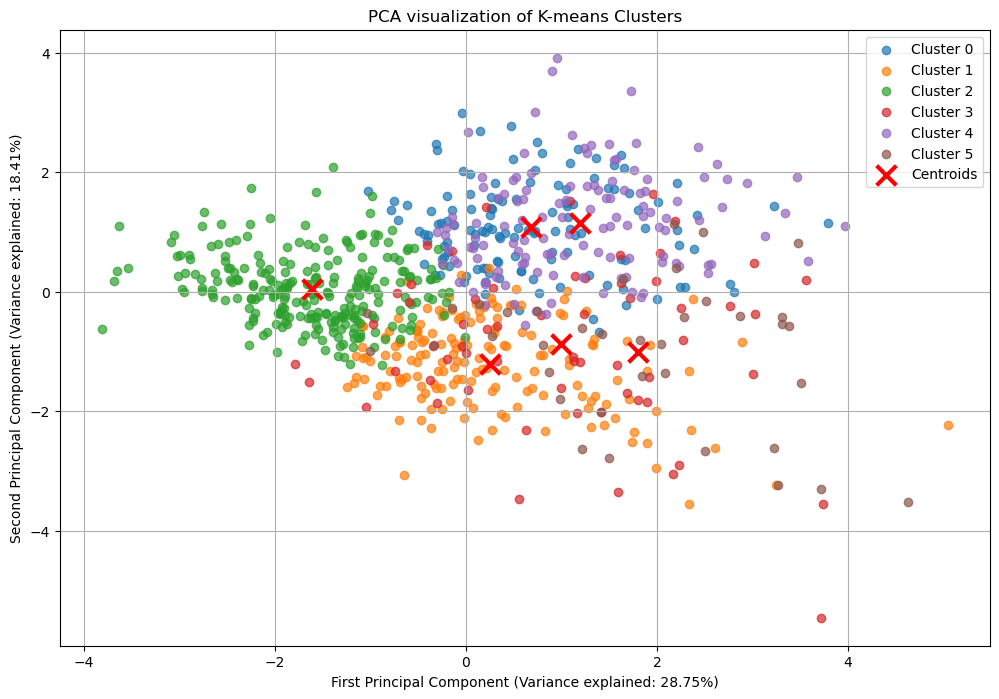


Top features contributing to Principal Component 1:
                    Feature  Importance
1                   Glucose    0.421065
7                       Age    0.393539
5                       BMI    0.390827
3             SkinThickness    0.390485
2             BloodPressure    0.378498
4                   Insulin    0.320583
0               Pregnancies    0.308371
6  DiabetesPedigreeFunction    0.146564

Top features contributing to Principal Component 2:
                    Feature  Importance
0               Pregnancies    0.552069
7                       Age    0.511603
5                       BMI    0.437935
3             SkinThickness    0.347245
6  DiabetesPedigreeFunction    0.271494
4                   Insulin    0.152909
2             BloodPressure    0.139202
1                   Glucose    0.068170


In [2]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create scatter plot
plt.figure(figsize=(12, 8))

# Plot each cluster
for cluster in range(optimal_k):
    mask = final_kmeans_model.labels_ == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Cluster {cluster}', 
               alpha=0.7)

# Plot centroids
centroids_pca = pca.transform(final_kmeans_model.centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='x', s=200, linewidths=3, 
           label='Centroids')

plt.title('PCA visualization of K-means Clusters')
plt.xlabel(f'First Principal Component (Variance explained: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Second Principal Component (Variance explained: {pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.grid(True)
plt.show()

# Print the feature importance for the first two principal components
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for i in range(2):
    print(f"\nTop features contributing to Principal Component {i+1}:")
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': abs(pca.components_[i])
    }).sort_values('Importance', ascending=False)
    print(feature_importance)

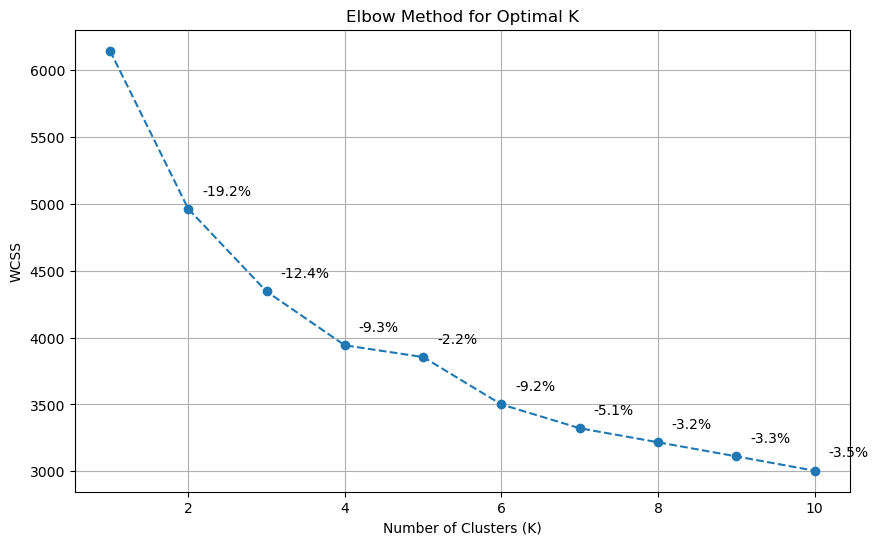

In [3]:
# Let's plot the elbow curve again with more clear annotations
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)

# Add annotations for the decrease in WCSS
for i in range(1, len(wcss)):
    decrease = wcss[i-1] - wcss[i]
    percentage = (decrease / wcss[i-1]) * 100
    plt.annotate(f'-{percentage:.1f}%', 
                xy=(i+1, wcss[i]),
                xytext=(10, 10),
                textcoords='offset points')

plt.show()

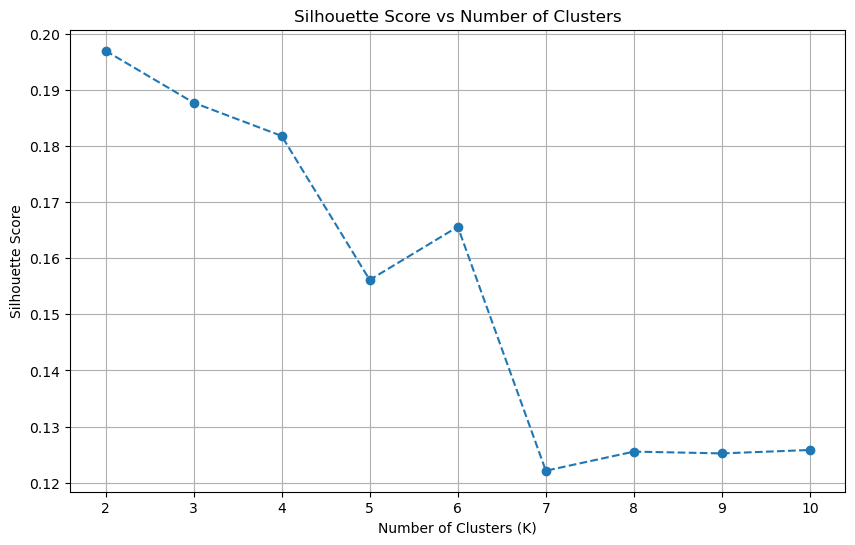

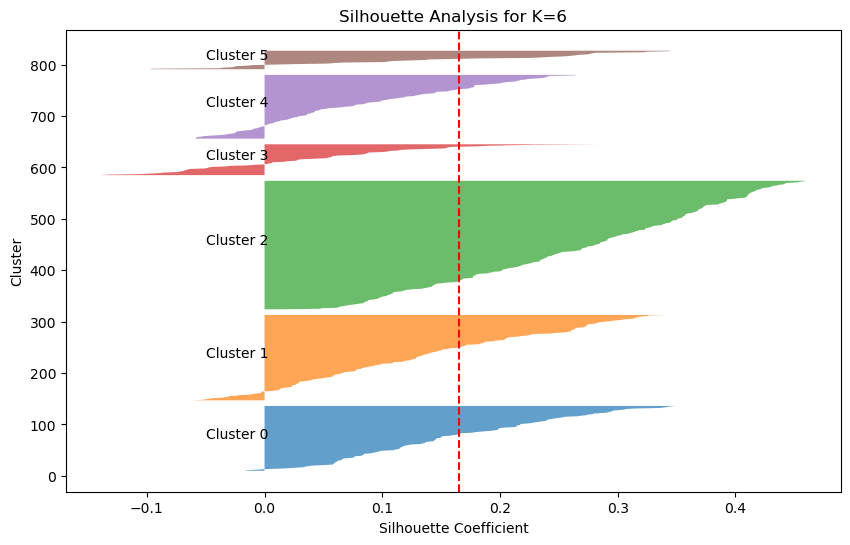


Silhouette Scores for different k values:
K=2: 0.197
K=3: 0.188
K=4: 0.182
K=5: 0.156
K=6: 0.166
K=7: 0.122
K=8: 0.126
K=9: 0.125
K=10: 0.126

Silhouette Score for optimal k=6: 0.166


In [4]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

import matplotlib.pyplot as plt

# Calculate silhouette scores for different k values
sil_scores = []
for k in range_n_clusters:
    if k <= 1:  # Skip k=1 as silhouette score needs at least 2 clusters
        continue
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil_scores, marker='o', linestyle='--')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Calculate detailed silhouette values for the optimal_k
silhouette_vals = silhouette_samples(X_scaled, final_kmeans_model.labels_)

# Plot detailed silhouette analysis for optimal_k
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[final_kmeans_model.labels_ == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      alpha=0.7)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}')
    y_lower = y_upper + 10

plt.title(f'Silhouette Analysis for K={optimal_k}')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')
plt.axvline(x=silhouette_score(X_scaled, final_kmeans_model.labels_), 
            color='red', linestyle='--')
plt.show()

# Print silhouette scores for all k values
print("\nSilhouette Scores for different k values:")
for k, score in zip(range(2, 11), sil_scores):
    print(f'K={k}: {score:.3f}')

print(f'\nSilhouette Score for optimal k={optimal_k}: {silhouette_score(X_scaled, final_kmeans_model.labels_):.3f}')

Okay, let's interpret each cluster from a medical point of view.

To do this effectively, We need to consider the features used for clustering and how the clusters differ in terms of these features. The key features in this dataset are:

*   **Pregnancies:** Number of times pregnant
*   **Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
*   **BloodPressure:** Diastolic blood pressure (mm Hg)
*   **SkinThickness:** Triceps skin fold thickness (mm)
*   **Insulin:** 2-Hour serum insulin (mu U/ml)
*   **BMI:** Body mass index (weight in kg/(height in m)\^2)
*   **DiabetesPedigreeFunction:** Diabetes pedigree function (a function which scores likelihood of diabetes based on family history)
*   **Age:** Age (years)

The notebook performs K-means clustering on a scaled version of these features (`X_scaled`). After clustering, it analyzes the distribution of the 'Outcome' variable (whether the person has diabetes or not) within each cluster.

Here's how we can interpret the clusters from a medical perspective:

1.  **Examine the Centroids:** The most direct way to understand the clusters is to look at the centroids of the `final_kmeans_model`. The notebook prints these centroids. Because the data is scaled, you'll need to remember that values near 0 are average, positive values are above average, and negative values are below average *for the scaled data*.

2.  **Analyze 'Outcome' Distribution:** The notebook calculates and prints the distribution of the 'Outcome' variable within each cluster. This is crucial. For example, if Cluster 0 has a high proportion of people with diabetes (Outcome=1), and Cluster 1 has a low proportion, that's a key distinguishing factor.

3.  **Relate Centroids to Outcome:** Combine the information from the centroids and the outcome distribution. For example:

    *   If a cluster has a high proportion of diabetic individuals *and* its centroid has high values for Glucose, BMI, and Age, you can interpret that cluster as representing a "High-Risk, Older, Overweight/Obese Diabetic Group."
    *   If a cluster has a low proportion of diabetic individuals *and* its centroid has low values for Glucose, BloodPressure, and BMI, you might interpret that as a "Low-Risk, Healthier Group."

4.  **Detailed Silhouette Analysis:** The notebook also includes code to perform a silhouette analysis. This can help you understand how well-separated the clusters are.

**Example Interpretation (Illustrative):**

Let's imagine (this is *hypothetical* based on what the *output* of the notebook *might* show):

*   **Cluster 0:** 70% diabetic. Centroid values: Glucose (+1.2), BMI (+0.8), Age (+0.9), Insulin (+0.5).
    *   **Interpretation:** "High-Risk Diabetic Group": Characterized by high glucose levels, higher BMI, older age, and somewhat elevated insulin. Likely represents individuals with existing diabetes or a very high risk of developing it soon.
*   **Cluster 1:** 15% diabetic. Centroid values: Glucose (-0.7), BMI (-0.6), Age (-0.5), Insulin (-0.4).
    *   **Interpretation:** "Lower-Risk Group": Characterized by lower glucose, BMI, age, and insulin levels. Likely represents individuals with a lower risk profile for diabetes.
*   **Cluster 2:** 40% diabetic. Centroid values: Glucose (+0.5), BMI (-0.2), Age (-0.1), Insulin (+1.0).
    *   **Interpretation:** "Insulin-Resistant Group": Characterized by moderately high glucose, near-average BMI and age, but *very* high insulin. This *might* represent individuals with insulin resistance, where their bodies are producing a lot of insulin but not using it effectively.
*   **Cluster 3:** 5% diabetic. Centroid values: All features are strongly negative.
    *   **Interpretation:** "Healthy group": Characterized by all features are below average. This is the most healthy group.